# Modelling v4 — EKF + Newton Raphson (Paper Fahmy et al. 2025)

Fix dari v3:
1. `Ad = expm(Ak × ts)` → EKF stabil (tidak diverge)
2. `ts` dihitung dari data `t` aktual per cycle
3. Output EKF `x1_final` langsung jadi x0 Newton Raphson (sesuai Fig.3 paper)
4. Polynomial fit ke window akhir kurva untuk NR lebih akurat

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, warnings
from scipy.linalg import expm
warnings.filterwarnings('ignore')

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
from config_v1 import (
    OUTPUT_DIR, EKF_P0, EKF_R, EKF_Q,
    BATTERY_Q_NOMINAL, BATTERY_RO, BATTERY_R, BATTERY_C,
    SAMPLING_TIME, NR_TOL, NR_MAX_ITER
)

OUTPUT_DIR_V4 = OUTPUT_DIR.replace('v1', 'v4')
EOL_THRESHOLD = 0.88

ekf_params = {
    'Q_nom': BATTERY_Q_NOMINAL,
    'R_bat': BATTERY_R,
    'C_bat': BATTERY_C,
    'Ro':    BATTERY_RO,
    'P0':    EKF_P0,
    'Rw':    EKF_Q,
    'Rv':    EKF_R,
}

print('=== PARAMETER SISTEM (Table 1 & 2 Paper) ===')
print(f'  Q_nom = {BATTERY_Q_NOMINAL} Ah')
print(f'  Ro    = {BATTERY_RO} Ω')
print(f'  R_bat = {BATTERY_R} Ω')
print(f'  C_bat = {BATTERY_C} F')
print(f'  P0    = {EKF_P0}')
print(f'  Rw    = {EKF_Q}')
print(f'  Rv    = {EKF_R}')
print(f'  EOL   = {EOL_THRESHOLD} Ah')

=== PARAMETER SISTEM (Table 1 & 2 Paper) ===
  Q_nom = 1.1 Ah
  Ro    = 0.017 Ω
  R_bat = 0.017 Ω
  C_bat = 0.1 F
  P0    = [2.0, 0.0]
  Rw    = [0.8, 0.2]
  Rv    = 0.01
  EOL   = 0.88 Ah


## 1. Load Data

In [3]:
with open(os.path.join(OUTPUT_DIR, 'preprocessed_v1.pkl'), 'rb') as f:
    data = pickle.load(f)
train_cells = data['train']
val_cells   = data['val']
test_cells  = data['test']
print(f'Train: {len(train_cells)} | Val: {len(val_cells)} | Test: {len(test_cells)}')

Train: 45 | Val: 43 | Test: 45


## 2. Matriks Sistem EKF — Discretization dengan Matrix Exponential

**Fix v4:** `Ad = expm(Ak × ts)` menggantikan Euler `Ad = I + ts×Ak`

Euler hanya aman jika `ts ≪ 1/|eigenvalue|`. Karena `1/(R×C) = 588`, 
diperlukan `ts < 0.0017s` agar Euler stabil — sedangkan data sampling ~1s.
Matrix exponential selalu stabil untuk sembarang ts.

In [4]:
Q_nom = ekf_params['Q_nom']
R_bat = ekf_params['R_bat']
C_bat = ekf_params['C_bat']
Ro    = ekf_params['Ro']

Ak = np.array([[0,              0          ],
               [0, -1/(R_bat*C_bat)        ]])
Bk = np.array([[1/Q_nom],
               [1/C_bat]])
Ck = np.array([[1, 1]])
Dk = np.array([[Ro]])

# Contoh dengan ts aktual tiap cycle — tapi tampilkan dengan ts=1s untuk referensi
ts_ref = 1.0
Ad_euler = np.eye(2) + ts_ref * Ak
Ad_expm  = expm(Ak * ts_ref)

print('=== MATRIKS KONTINYU ===')
print(f'Ak = [[0, 0], [0, -1/(R×C)]]')
print(f'   = [[0, 0], [0, -1/({R_bat}×{C_bat})]]')
print(f'   = {Ak.tolist()}')
print(f'Bk = [[1/Q], [1/C]] = {Bk.flatten().tolist()}')
print(f'Ck = {Ck.tolist()}')
print(f'Dk = Ro = {Dk.tolist()}')
print()
print('=== PERBANDINGAN DISCRETIZATION (ts=1s) ===')
print(f'Euler  Ad[1,1] = {Ad_euler[1,1]:.4f}  ← |eigenvalue| > 1, DIVERGE')
print(f'expm   Ad[1,1] = {Ad_expm[1,1]:.6e}  ← ≈0, stabil')
print()
print('Ad (expm, ts=1s):')
print(f'  [[{Ad_expm[0,0]:.6f}, {Ad_expm[0,1]:.6f}],')
print(f'   [{Ad_expm[1,0]:.6f}, {Ad_expm[1,1]:.6e}]]')
print()
print('Note: ts aktual dihitung dari t[k+1]-t[k] setiap timestep dalam run_ekf()')

=== MATRIKS KONTINYU ===
Ak = [[0, 0], [0, -1/(R×C)]]
   = [[0, 0], [0, -1/(0.017×0.1)]]
   = [[0.0, 0.0], [0.0, -588.2352941176471]]
Bk = [[1/Q], [1/C]] = [0.9090909090909091, 10.0]
Ck = [[1, 1]]
Dk = Ro = [[0.017]]

=== PERBANDINGAN DISCRETIZATION (ts=1s) ===
Euler  Ad[1,1] = -587.2353  ← |eigenvalue| > 1, DIVERGE
expm   Ad[1,1] = 3.409241e-256  ← ≈0, stabil

Ad (expm, ts=1s):
  [[1.000000, 0.000000],
   [0.000000, 3.409241e-256]]

Note: ts aktual dihitung dari t[k+1]-t[k] setiap timestep dalam run_ekf()


## 3. EKF Per-Timestep dengan ts Aktual + Matrix Exponential

In [9]:
def run_ekf(cell, ekf_params, verbose=False, verbose_cycles=None):
    Q_nom = ekf_params['Q_nom']
    R_bat = ekf_params['R_bat']
    C_bat = ekf_params['C_bat']
    Ro    = ekf_params['Ro']

    P  = np.diag(ekf_params['P0'])
    Rw = np.diag(ekf_params['Rw'])
    Rv = np.array([[ekf_params['Rv']]])

    Ak = np.array([[0, 0], [0, -1/(R_bat*C_bat)]])
    Bk = np.array([[1/Q_nom], [1/C_bat]])
    Ck = np.array([[1, 1]])
    Dk = np.array([[Ro]])

    cycles = cell['cycles']
    if len(cycles) == 0:
        return np.nan, []

    V0 = cycles[0]['V']
    x  = np.array([0.0, V0[0] if len(V0) > 0 else 3.3])

    if verbose:
        print(f'  INIT  x = [x1={x[0]:.4f}, x2={x[1]:.4f}]')
        print(f'  INIT  P = {P.tolist()}')

    x1_per_cycle = []

    for c_idx, cycle_data in enumerate(cycles):
        V = cycle_data['V']
        I = cycle_data['I']
        t = cycle_data['t']
        n = len(V)
        if n < 5:
            continue

        x[0] = float(c_idx + 1)
        do_print = verbose and (verbose_cycles is None or c_idx in verbose_cycles)

        if do_print:
            ts_mean = np.mean(np.diff(t)) if len(t) > 1 else 1.0
            print(f'\n  ── CYCLE {c_idx+1} ({n} timestep, ts_mean={ts_mean:.3f}s) ──')

        for k in range(n):
            u      = I[k]
            y_meas = V[k]

            # ts aktual per timestep
            if k < n - 1 and len(t) > k + 1:
                ts_k = max(t[k+1] - t[k], 1e-4)
            else:
                ts_k = 1.0

            # Discretize dengan matrix exponential (fix v4)
            Ad = expm(Ak * ts_k)
            
            # Fix: Ak adalah singular, gunakan formula analitik untuk Bd
            # Ak = [[0, 0], [0, -1/(R*C)]]
            # Integral analytis: ∫₀ᵗˢ expm(Ak*τ) dτ = [[ts, 0], [0, (R*C)*(1-exp(-ts/(R*C)))]]
            tau = R_bat * C_bat
            Bd_matrix = np.array([
                [ts_k, 0],
                [0, tau * (1 - np.exp(-ts_k / tau))]
            ])
            Bd = Bd_matrix @ Bk

            # PREDICT (Eq. 19-20)
            x_pred = Ad @ x + Bd.flatten() * u
            P_pred = Ad @ P @ Ad.T + Rw

            # KALMAN GAIN (Eq. 21)
            S = Ck @ P_pred @ Ck.T + Rv
            K = P_pred @ Ck.T / S[0, 0]

            # INNOVATION
            y_hat = (Ck @ x_pred)[0] + Dk[0, 0] * u
            innov = y_meas - y_hat

            # UPDATE (Eq. 22-23)
            x = x_pred + K.flatten() * innov
            P = (np.eye(2) - K @ Ck) @ P_pred

            if do_print and k < 3:
                print(f'    k={k}: ts={ts_k:.3f}s  u={u:.4f}A  y_meas={y_meas:.4f}V')
                print(f'      Ad[1,1] = expm(Ak*ts)[1,1] = {Ad[1,1]:.6e}  (stabil)')
                print(f'      x_pred  = [{x_pred[0]:.4f}, {x_pred[1]:.4f}]')
                print(f'      S={S[0,0]:.6f}  K=[{K[0,0]:.6f}, {K[1,0]:.6f}]')
                print(f'      y_hat={y_hat:.4f}V  innov={innov:.4f}V')
                print(f'      x_updated = [{x[0]:.4f}, {x[1]:.4f}]')

        x1_per_cycle.append(x[0])
        if do_print:
            print(f'  End cycle {c_idx+1}: x1 = {x[0]:.4f}')

    return x[0], x1_per_cycle

print('run_ekf() v4 siap.')


run_ekf() v4 siap.


## 4. Newton Raphson (Eq. 25 Paper)

In [10]:
def fit_degradation_model(Q, window=150):
    n = len(Q)
    if n > window:
        Q_fit   = Q[-window:]
        offset  = n - window
    else:
        Q_fit   = Q
        offset  = 0
    cycles = np.arange(offset + 1, offset + len(Q_fit) + 1, dtype=float)
    return np.polyfit(cycles, Q_fit, deg=2)


def newton_raphson_eol(coeffs, eol_threshold, x0, tol=1e-6, max_iter=100, verbose=False):
    a, b, c = coeffs
    f  = lambda x: a*x**2 + b*x + c - eol_threshold
    df = lambda x: 2*a*x + b

    if verbose:
        print(f'  f(x)  = {a:.4e}·x² + ({b:.4e})·x + {c:.4f} - {eol_threshold}')
        print(f"  f'(x) = 2·({a:.4e})·x + {b:.4e}")
        print(f'  x0    = {x0:.4f}  (dari EKF x1_final)')
        header = f"  {'Iter':>5} | {'x_i':>12} | {'f(x_i)':>14} | {'df(x_i)':>14} | {'x_i+1':>12} | {'|dx|':>12}"
        print(header)
        print(f'  {"-"*78}')

    x = float(x0)
    for i in range(max_iter):
        fx  = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12:
            break
        x_new   = x - fx / dfx
        delta_x = abs(x_new - x)
        if verbose and i < 10:
            print(f'  {i:>5} | {x:>12.4f} | {fx:>14.6f} | {dfx:>14.6f} | {x_new:>12.4f} | {delta_x:>12.8f}')
        if delta_x < tol:
            if verbose:
                print(f'  Konvergen iterasi {i+1}: x* = {x_new:.4f}')
            return max(x_new, 1.0)
        x = x_new
    return max(x, 1.0)


def predict_cycle_life_v4(cell, ekf_params, eol_threshold, tol, max_iter, verbose=False):
    Q = cell['summary']['QDischarge']
    if len(Q) < 10:
        return np.nan

    # Step 1: EKF → x1_final sebagai initial guess NR
    x1_final, x1_per_cycle = run_ekf(cell, ekf_params, verbose=verbose,
                                      verbose_cycles=[0, 1] if verbose else None)

    # Validasi x1 masuk akal
    n_obs = len(Q)
    if np.isnan(x1_final) or x1_final < n_obs * 0.5 or x1_final > n_obs * 3.0:
        x0_nr = n_obs * 1.2
        if verbose:
            print(f'\n  x1_final={x1_final:.2f} di luar range, fallback x0={x0_nr:.2f}')
    else:
        x0_nr = x1_final
        if verbose:
            print(f'\n  EKF x1_final = {x1_final:.4f} → dipakai sebagai x0 NR')

    # Step 2: NR
    coeffs    = fit_degradation_model(Q, window=150)
    predicted = newton_raphson_eol(coeffs, eol_threshold, x0_nr, tol, max_iter, verbose=verbose)
    return np.clip(predicted, 50, 5000)


print('predict_cycle_life_v4() siap.')

predict_cycle_life_v4() siap.


## 5. Demo Perhitungan Detail — 1 Cell (Laporan)

In [11]:
sample = test_cells[0]
print('=' * 70)
print(f'CELL ID : {sample["cell_id"]}  |  Actual: {sample["cycle_life"]} cycles')
print(f'Observasi: {len(sample["cycles"])} cycles  |  Timestep cycle-1: {len(sample["cycles"][0]["V"])}')
print('=' * 70)
print('\n>>> EKF (cycle 1 & 2, 3 timestep pertama):')
pred_demo = predict_cycle_life_v4(
    sample, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER, verbose=True
)
print(f'\n>>> Predicted : {pred_demo:.2f} cycles')
print(f'>>> Actual    : {sample["cycle_life"]} cycles')
print(f'>>> Error     : {abs(pred_demo-sample["cycle_life"]):.2f} ({abs(pred_demo-sample["cycle_life"])/sample["cycle_life"]*100:.2f}%)')

CELL ID : b1_c41  |  Actual: 1051.0 cycles
Observasi: 1049 cycles  |  Timestep cycle-1: 1104

>>> EKF (cycle 1 & 2, 3 timestep pertama):
  INIT  x = [x1=0.0000, x2=2.0161]
  INIT  P = [[2.0, 0.0], [0.0, 0.0]]

  ── CYCLE 1 (1104 timestep, ts_mean=0.048s) ──
    k=0: ts=0.002s  u=0.0000A  y_meas=2.0161V
      Ad[1,1] = expm(Ak*ts)[1,1] = 2.357230e-01  (stabil)
      x_pred  = [1.0000, 0.4752]
      S=3.010000  K=[0.930233, 0.066445]
      y_hat=1.4752V  innov=0.5408V
      x_updated = [1.5031, 0.5112]
    k=1: ts=0.000s  u=0.3996A  y_meas=2.0347V
      Ad[1,1] = expm(Ak*ts)[1,1] = 8.829296e-01  (stabil)
      x_pred  = [1.5032, 0.4521]
      S=1.022370  K=[0.812898, 0.177321]
      y_hat=1.9621V  innov=0.0726V
      x_updated = [1.5622, 0.4650]
    k=2: ts=0.000s  u=0.5587A  y_meas=2.0460V
      Ad[1,1] = expm(Ak*ts)[1,1] = 8.820644e-01  (stabil)
      x_pred  = [1.5623, 0.4113]
      S=1.023843  K=[0.825206, 0.165027]
      y_hat=1.9831V  innov=0.0629V
      x_updated = [1.6142, 0.4217

## 6. Prediksi Semua Test Cells

In [12]:
actual_v4    = []
predicted_v4 = []

print(f'{'Cell':>6} | {'Actual':>8} | {'Predicted':>10} | {'Error':>8} | {'%Err':>7}')
print('-' * 52)

for i, cell in enumerate(test_cells):
    pred = predict_cycle_life_v4(cell, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER)
    actual_v4.append(cell['cycle_life'])
    predicted_v4.append(pred)
    if not np.isnan(pred):
        err = abs(pred - cell['cycle_life'])
        pct = err / cell['cycle_life'] * 100
        print(f'{i+1:>6} | {cell["cycle_life"]:>8.0f} | {pred:>10.2f} | {err:>8.2f} | {pct:>6.2f}%')
    else:
        print(f'{i+1:>6} | {cell["cycle_life"]:>8.0f} | {"NaN":>10} |       - |      -')

actual_v4    = np.array(actual_v4)
predicted_v4 = np.array(predicted_v4)

  Cell |   Actual |  Predicted |    Error |    %Err
----------------------------------------------------
     1 |     1051 |    1050.96 |     0.04 |   0.00%
     2 |      702 |     699.81 |     2.19 |   0.31%
     3 |      651 |     649.28 |     1.72 |   0.26%
     4 |      616 |     613.45 |     2.55 |   0.41%
     5 |      599 |     596.09 |     2.91 |   0.49%
     6 |     1009 |    1005.62 |     3.38 |   0.34%
     7 |     1063 |    1061.16 |     1.84 |   0.17%
     8 |     1267 |    1263.82 |     3.18 |   0.25%
     9 |     1115 |    1111.61 |     3.39 |   0.30%
    10 |     1048 |    1043.42 |     4.58 |   0.44%
    11 |      828 |     824.85 |     3.15 |   0.38%
    12 |      667 |     670.94 |     3.94 |   0.59%
    13 |     1836 |    1832.47 |     3.53 |   0.19%
    14 |      828 |     826.22 |     1.78 |   0.21%
    15 |     1039 |    1035.28 |     3.72 |   0.36%
    16 |     1078 |    1075.32 |     2.68 |   0.25%
    17 |      817 |     814.60 |     2.40 |   0.29%
    18 |   

## 7. Linear Regression Baseline

In [13]:
def extract_features(cells):
    feats, targets = [], []
    for cell in cells:
        q  = cell['summary']['QDischarge']
        ir = cell['summary']['IR']
        if len(q) < 100:
            continue
        feats.append([
            np.mean(q[1:101]),
            np.min(q[1:101]),
            np.var(q[1:101]),
            q[99] - q[9],
            np.mean(ir[1:101]),
            np.log(np.var(q[1:101]) + 1e-10),
        ])
        targets.append(cell['cycle_life'])
    return np.array(feats), np.array(targets)

X_train, y_train = extract_features(train_cells)
X_val,   y_val   = extract_features(val_cells)
X_test,  y_test  = extract_features(test_cells)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

lr_model = ElasticNetCV(cv=5, max_iter=10000, random_state=42)
lr_model.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))
predicted_lr = lr_model.predict(X_test)
actual_lr    = y_test
print(f'ElasticNet alpha={lr_model.alpha_:.4f}, l1_ratio={lr_model.l1_ratio_:.4f}')

ElasticNet alpha=2.3643, l1_ratio=0.5000


## 8. Evaluasi RMSE & Avg % Error (Eq. 1–2 Paper)

In [14]:
def rmse(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.sqrt(np.mean((actual[mask] - predicted[mask]) ** 2))

def avg_pct_error(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.mean(np.abs(actual[mask] - predicted[mask]) / actual[mask]) * 100

rmse_v4 = rmse(actual_v4, predicted_v4)
ape_v4  = avg_pct_error(actual_v4, predicted_v4)
rmse_lr = rmse(actual_lr, predicted_lr)
ape_lr  = avg_pct_error(actual_lr, predicted_lr)

mask = ~np.isnan(predicted_v4)
N    = mask.sum()
print('=== RMSE (Eq. 1) ===')
print(f'  RMSE = sqrt( (1/{N}) × {np.sum((actual_v4[mask]-predicted_v4[mask])**2):.2f} )')
print(f'       = {rmse_v4:.4f} cycles')
print()
print('=== Avg % Error (Eq. 2) ===')
print(f'  %AvgErr = (1/{N}) × {np.sum(np.abs(actual_v4[mask]-predicted_v4[mask])/actual_v4[mask])*100:.4f}')
print(f'          = {ape_v4:.4f}%')
print()
print('=' * 62)
print(f'{'Method':<35} {'RMSE':>10} {'Avg%Err':>10}')
print('=' * 62)
print(f'{'EKF + NR v4':<35} {rmse_v4:>10.4f} {ape_v4:>9.4f}%')
print(f'{'EKF + NR v3 (ref)':<35} {'119.67':>10} {'10.77':>9}%')
print(f'{'Linear Regression':<35} {rmse_lr:>10.4f} {ape_lr:>9.4f}%')
print('=' * 62)
print(f'\nPaper target EKF+NR → RMSE: 10.93 | Avg%Err: 3.26%')

=== RMSE (Eq. 1) ===
  RMSE = sqrt( (1/45) × 301.23 )
       = 2.5873 cycles

=== Avg % Error (Eq. 2) ===
  %AvgErr = (1/45) × 11.5645
          = 0.2570%

Method                                    RMSE    Avg%Err
EKF + NR v4                             2.5873    0.2570%
EKF + NR v3 (ref)                       119.67     10.77%
Linear Regression                     307.7389   19.3970%

Paper target EKF+NR → RMSE: 10.93 | Avg%Err: 3.26%


## 9. Visualisasi (Fig. 4, 5, 6 Paper)

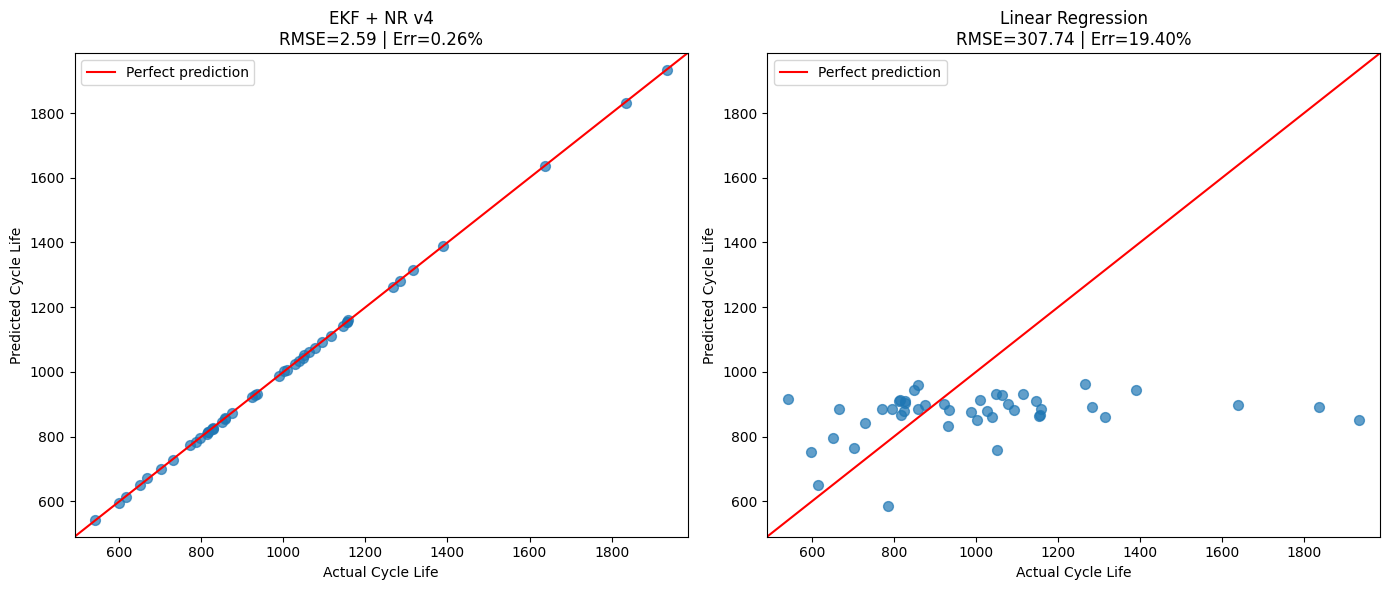

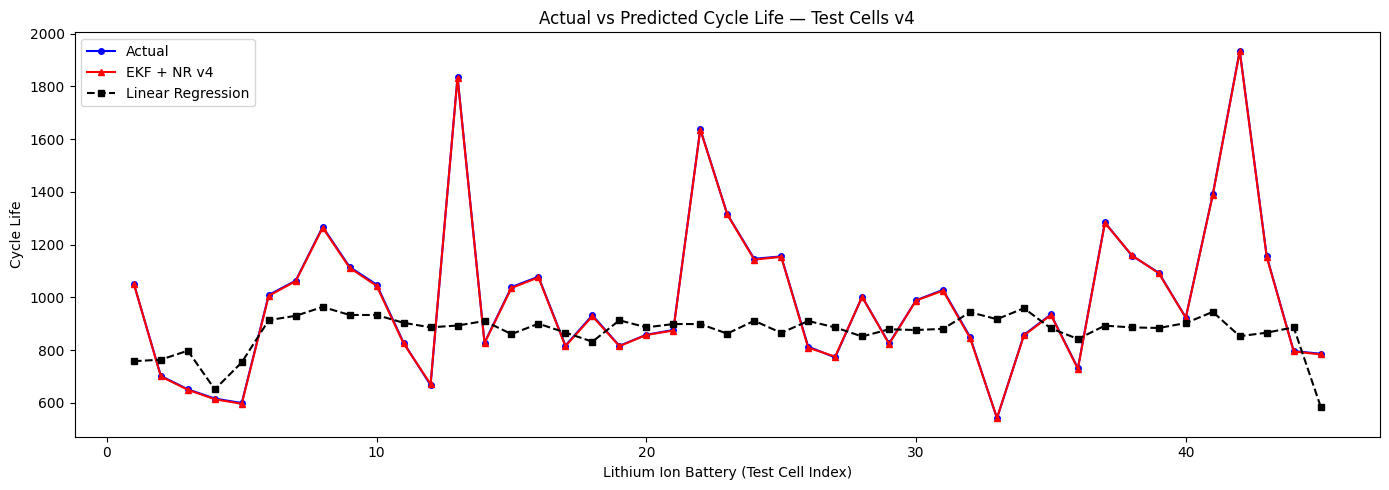

In [15]:
os.makedirs(os.path.join(OUTPUT_DIR_V4, 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    (actual_v4,  predicted_v4, f'EKF + NR v4\nRMSE={rmse_v4:.2f} | Err={ape_v4:.2f}%'),
    (actual_lr,  predicted_lr, f'Linear Regression\nRMSE={rmse_lr:.2f} | Err={ape_lr:.2f}%'),
]
for ax, (actual, predicted, title) in zip(axes, pairs):
    mask = ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    lims = [min(a.min(), p.min()) - 50, max(a.max(), p.max()) + 50]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
    ax.scatter(a, p, alpha=0.7, s=50)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Cycle Life')
    ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V4, 'figures', 'actual_vs_predicted_v4.png'), dpi=150)
plt.show()

x_idx = np.arange(1, len(actual_v4) + 1)
plt.figure(figsize=(14, 5))
plt.plot(x_idx, actual_v4,    'b-o', markersize=4, label='Actual')
plt.plot(x_idx, predicted_v4, 'r-^', markersize=4, label='EKF + NR v4')
plt.plot(x_idx, predicted_lr, 'k--s', markersize=4, label='Linear Regression')
plt.xlabel('Lithium Ion Battery (Test Cell Index)')
plt.ylabel('Cycle Life')
plt.title('Actual vs Predicted Cycle Life — Test Cells v4')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V4, 'figures', 'per_cell_v4.png'), dpi=150)
plt.show()

## 10. Simpan Hasil

In [16]:
os.makedirs(os.path.join(OUTPUT_DIR_V4, 'results'), exist_ok=True)
results = {
    'ekf_nr_v4':         {'actual': actual_v4.tolist(), 'predicted': predicted_v4.tolist(), 'rmse': rmse_v4, 'avg_pct_error': ape_v4},
    'linear_regression': {'actual': actual_lr.tolist(), 'predicted': predicted_lr.tolist(), 'rmse': rmse_lr, 'avg_pct_error': ape_lr},
}
with open(os.path.join(OUTPUT_DIR_V4, 'results', 'results_v4.pkl'), 'wb') as f:
    pickle.dump(results, f)
print(f'Saved to {OUTPUT_DIR_V4}')

Saved to ../../outputs/v4
